# Assignment 5

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
from sklearn.preprocessing import StandardScaler


dfX = pd.read_csv("datasets/X.txt", sep=";")#, header=None)

dfY = pd.read_csv("datasets/Y.txt", sep=";")


for i in range(len(dfX["IsDayBin"].values)):
    if dfX["IsDayBin"].values[i] == "Night":
        dfX["IsDayBin"].values[i] = 0
    else:
        dfX["IsDayBin"].values[i] = 1

scaler = StandardScaler()

XScaled = pd.DataFrame(scaler.fit_transform(dfX), columns=dfX.columns)

X = XScaled.copy()
y_wind = dfY['WindPower'].values
y_pv   = dfY['PVPower'].values

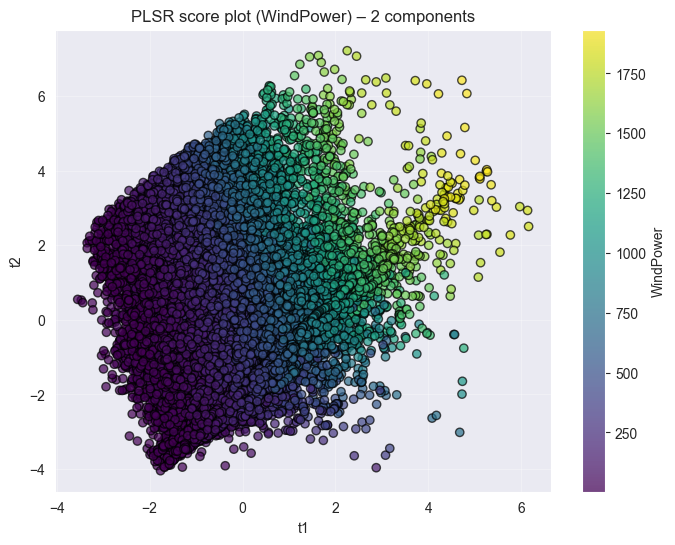

In [4]:
# Fit PLSR with 2 components for WindPower
pls_wind = PLSRegression(n_components=2)
pls_wind.fit(X, y_wind)

#
t1 = pls_wind.x_scores_[:, 0]
t2 = pls_wind.x_scores_[:, 1]

plt.figure(figsize=(8,6))
sc = plt.scatter(t1, t2, c=y_wind, cmap='viridis', edgecolor='k', alpha=0.7)
plt.colorbar(sc, label='WindPower')
plt.xlabel('t1')
plt.ylabel('t2')
plt.title('PLSR score plot (WindPower) – 2 components')
plt.grid(alpha=0.3)
plt.show()

In [5]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import mean_squared_error, r2_score

# Fit PLSR for a range of components (1 to 10)
max_comps = 10
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmsep_wind_cv = []
rmsep_pv_cv = []
r2_wind_cv = []
r2_pv_cv = []

for k in range(1, max_comps + 1):
    pls_wind = PLSRegression(n_components=k)
    pls_pv = PLSRegression(n_components=k)

    y_pred_wind = cross_val_predict(pls_wind, X, y_wind, cv=kf)
    y_pred_pv = cross_val_predict(pls_pv, X, y_pv, cv=kf)

    rmsep_wind_cv.append(np.sqrt(mean_squared_error(y_wind, y_pred_wind)))
    rmsep_pv_cv.append(np.sqrt(mean_squared_error(y_pv, y_pred_pv)))
    r2_wind_cv.append(r2_score(y_wind, y_pred_wind))
    r2_pv_cv.append(r2_score(y_pv, y_pred_pv))

# Plot RMSEP vs number of components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, max_comps + 1), rmsep_wind_cv, marker='o', color=BLUE)
axes[0].set_xlabel('Number of components')
axes[0].set_ylabel('RMSEP (CV)')
axes[0].set_title('WindPower: Cross‑validated RMSEP')
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, max_comps + 1), rmsep_pv_cv, marker='o', color=ORANGE)
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('RMSEP (CV)')
axes[1].set_title('PVPower: Cross‑validated RMSEP')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print CV results
print("WindPower CV results:")
for i in range(max_comps):
    print(f"  {i + 1} comps: RMSEP={rmsep_wind_cv[i]:.4f}, R²={r2_wind_cv[i]:.4f}")
print("\nPVPower CV results:")
for i in range(max_comps):
    print(f"  {i + 1} comps: RMSEP={rmsep_pv_cv[i]:.4f}, R²={r2_pv_cv[i]:.4f}")

# Choose optimal number of components (e.g., where RMSEP stabilises)
# For demonstration we use 3 for both (to compare directly with PCR)
opt_comps_wind = 3
opt_comps_pv = 3

# Fit final models
pls_wind_opt = PLSRegression(n_components=opt_comps_wind)
pls_wind_opt.fit(X, y_wind)
pls_pv_opt = PLSRegression(n_components=opt_comps_pv)
pls_pv_opt.fit(X, y_pv)

# Predictions
y_pred_wind_pls = pls_wind_opt.predict(X)
y_pred_pv_pls = pls_pv_opt.predict(X)

r2_wind_pls = r2_score(y_wind, y_pred_wind_pls)
r2_pv_pls = r2_score(y_pv, y_pred_pv_pls)
rmse_wind_pls = np.sqrt(mean_squared_error(y_wind, y_pred_wind_pls))
rmse_pv_pls = np.sqrt(mean_squared_error(y_pv, y_pred_pv_pls))

print(f"\nPLSR with {opt_comps_wind} components – WindPower: R²={r2_wind_pls:.4f}, RMSE={rmse_wind_pls:.4f}")
print(f"PLSR with {opt_comps_pv} components – PVPower:   R²={r2_pv_pls:.4f}, RMSE={rmse_pv_pls:.4f}")

# Compare with MLR and PCR
print("\nComparison of R² values:")
print(f"  WindPower: MLR={r2_wind_ols:.4f}, PCR(3)={r2WindPcr:.4f}, PLSR({opt_comps_wind})={r2_wind_pls:.4f}")
print(f"  PVPower:   MLR={r2_pv_ols:.4f},   PCR(3)={r2PvPcr:.4f},   PLSR({opt_comps_pv})={r2_pv_pls:.4f}")

#### PLSR Score Plots

# Score plot for WindPower
t1_wind = pls_wind_opt.x_scores_[:, 0]
t2_wind = pls_wind_opt.x_scores_[:, 1]

fig_wind = px.scatter(x=t1_wind, y=t2_wind, color=y_wind,
                      color_continuous_scale='viridis',
                      title=f'PLSR Score Plot (WindPower) – {opt_comps_wind} components (t1 vs t2)',
                      labels={'x': 't1', 'y': 't2', 'color': 'WindPower'})
fig_wind.update_layout(coloraxis_colorbar_title='WindPower')
fig_wind.show()

# Score plot for PVPower
t1_pv = pls_pv_opt.x_scores_[:, 0]
t2_pv = pls_pv_opt.x_scores_[:, 1]

fig_pv = px.scatter(x=t1_pv, y=t2_pv, color=y_pv,
                    color_continuous_scale='viridis',
                    title=f'PLSR Score Plot (PVPower) – {opt_comps_pv} components (t1 vs t2)',
                    labels={'x': 't1', 'y': 't2', 'color': 'PVPower'})
fig_pv.update_layout(coloraxis_colorbar_title='PVPower')
fig_pv.show()

#### Weights and Loadings

# WindPower weights
weights_wind = pls_wind_opt.x_weights_
weights_df_wind = pd.DataFrame(weights_wind,
                               index=[f'Comp{i + 1}' for i in range(opt_comps_wind)],
                               columns=X.columns)

print("Weights for WindPower PLS (first two components):")
print(weights_df_wind.round(3))

# Bar plot for first two components
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Component 1
w1 = weights_df_wind.iloc[0].sort_values()
colors = ['red' if w < 0 else BLUE for w in w1]
axes[0].barh(w1.index, w1.values, color=colors, alpha=0.7)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('WindPower PLS: Weights for Component 1')
axes[0].set_xlabel('Weight')
axes[0].grid(alpha=0.3, axis='x')
# Component 2 (if exists)
if opt_comps_wind >= 2:
    w2 = weights_df_wind.iloc[1].sort_values()
    colors = ['red' if w < 0 else BLUE for w in w2]
    axes[1].barh(w2.index, w2.values, color=colors, alpha=0.7)
    axes[1].axvline(0, color='black', linewidth=0.5)
    axes[1].set_title('WindPower PLS: Weights for Component 2')
    axes[1].set_xlabel('Weight')
    axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# PVPower weights
weights_pv = pls_pv_opt.x_weights_
weights_df_pv = pd.DataFrame(weights_pv,
                             index=[f'Comp{i + 1}' for i in range(opt_comps_pv)],
                             columns=X.columns)
print("\nWeights for PVPower PLS (first two components):")
print(weights_df_pv.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Component 1
w1_pv = weights_df_pv.iloc[0].sort_values()
colors = ['red' if w < 0 else ORANGE for w in w1_pv]
axes[0].barh(w1_pv.index, w1_pv.values, color=colors, alpha=0.7)
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].set_title('PVPower PLS: Weights for Component 1')
axes[0].set_xlabel('Weight')
axes[0].grid(alpha=0.3, axis='x')
if opt_comps_pv >= 2:
    w2_pv = weights_df_pv.iloc[1].sort_values()
    colors = ['red' if w < 0 else ORANGE for w in w2_pv]
    axes[1].barh(w2_pv.index, w2_pv.values, color=colors, alpha=0.7)
    axes[1].axvline(0, color='black', linewidth=0.5)
    axes[1].set_title('PVPower PLS: Weights for Component 2')
    axes[1].set_xlabel('Weight')
    axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Correlation Loading Plot (PLS version)

# For WindPower
scores_wind = pls_wind_opt.x_scores_
corr_x_scores_wind = pd.DataFrame(index=X.columns,
                                  columns=[f'Comp{i + 1}' for i in range(opt_comps_wind)])
for j in range(opt_comps_wind):
    for i, col in enumerate(X.columns):
        corr = np.corrcoef(X.iloc[:, i], scores_wind[:, j])[0, 1]
        corr_x_scores_wind.iloc[i, j] = corr
print("Correlations between X and PLS scores (WindPower):")
print(corr_x_scores_wind.round(3))

# For PVPower
scores_pv = pls_pv_opt.x_scores_
corr_x_scores_pv = pd.DataFrame(index=X.columns,
                                columns=[f'Comp{i + 1}' for i in range(opt_comps_pv)])
for j in range(opt_comps_pv):
    for i, col in enumerate(X.columns):
        corr = np.corrcoef(X.iloc[:, i], scores_pv[:, j])[0, 1]
        corr_x_scores_pv.iloc[i, j] = corr
print("\nCorrelations between X and PLS scores (PVPower):")
print(corr_x_scores_pv.round(3))

# Plot correlation loading plot for first two components (if available)
if opt_comps_wind >= 2:
    fig, ax = plt.subplots(figsize=(10, 10))
    circle = plt.Circle((0, 0), 1, fill=False, color='black')
    ax.add_patch(circle)

    for i, col in enumerate(X.columns):
        xc = corr_x_scores_wind.iloc[i, 0]
        yc = corr_x_scores_wind.iloc[i, 1]
        ax.arrow(0, 0, xc, yc, head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.7)
        ax.text(xc * 1.1, yc * 1.1, col, fontsize=9, ha='center', va='center')

    # Add the response correlation as a star
    r_wind_c1 = np.corrcoef(y_wind, scores_wind[:, 0])[0, 1]
    r_wind_c2 = np.corrcoef(y_wind, scores_wind[:, 1])[0, 1]
    ax.scatter(r_wind_c1, r_wind_c2, marker='*', s=200, color='red', label='WindPower')

    ax.set_xlim(-1.2, 1.2);
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Correlation with Component 1')
    ax.set_ylabel('Correlation with Component 2')
    ax.set_title('PLS Correlation Loading Plot (WindPower)')
    ax.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Similarly for PVPower
if opt_comps_pv >= 2:
    fig, ax = plt.subplots(figsize=(10, 10))
    circle = plt.Circle((0, 0), 1, fill=False, color='black')
    ax.add_patch(circle)

    for i, col in enumerate(X.columns):
        xc = corr_x_scores_pv.iloc[i, 0]
        yc = corr_x_scores_pv.iloc[i, 1]
        ax.arrow(0, 0, xc, yc, head_width=0.05, head_length=0.05, fc='gray', ec='gray', alpha=0.7)
        ax.text(xc * 1.1, yc * 1.1, col, fontsize=9, ha='center', va='center')

    r_pv_c1 = np.corrcoef(y_pv, scores_pv[:, 0])[0, 1]
    r_pv_c2 = np.corrcoef(y_pv, scores_pv[:, 1])[0, 1]
    ax.scatter(r_pv_c1, r_pv_c2, marker='*', s=200, color='gold', label='PVPower')

    ax.set_xlim(-1.2, 1.2);
    ax.set_ylim(-1.2, 1.2)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Correlation with Component 1')
    ax.set_ylabel('Correlation with Component 2')
    ax.set_title('PLS Correlation Loading Plot (PVPower)')
    ax.legend()
    plt.grid(alpha=0.3)
    plt.show()


SyntaxError: invalid syntax (149026423.py, line 104)